# Hands-on Introduction

In this notebook, there are two datasets -- tabular data and imaging data. Both datasets are used to derive stellar mass, but given a taste of different types of datasets, as well as different dimensions. 

## Tabular Data
We will use a catalogue named `known_datasets.csv`. The exercises aim to derive stellar mass with given physical properties. You are free to combine any properties you like as predictors, but be aware that not every properties are useful in predicting stellar mass.

This catalogue contains some galaxy properties for Galaxy Zoo 2 samples, obtained from __[Willett et al.(2013)](https://ui.adsabs.harvard.edu/abs/2013MNRAS.435.2835W/abstract)__, __[Mendel et al. (2014)](http://ui.adsabs.harvard.edu/abs/2014ApJS..210....3M/abstract)__, and __[Simard et al. (2011)](https://ui.adsabs.harvard.edu/abs/2011ApJS..196...11S/abstract)__

**Glossary**
* *z*: redshift
* *logM*: Total stellar mass
* *(g,r)mag*: Apparent magnitudes in g,r-bands
* *(g,r)Mag*: Absolute magnitudes in g,r-bands
* *g-r*: colour obtained from `gMag - rMag`
* *B_T_r*: Bulge-to-total ratio (bulge fraction) in r-band
* *e*: Galaxy ellipticity
* *n*: Galaxy Sersic index

## Imaging Data
The galaxy images are located in the folder `known_datasets_imgs/`. The exercises aim to use pixel information to derive stellar mass. For each sample, the corresponding stellar mass is written at the end of their filenames, e.g. "*587722982282035453-`11.214`.jpg*"

In [43]:
#### Import library you need here ####

## General Package ##
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## for reading images ##
from PIL import Image

In [2]:
#### Helper function ####

def evaluate(y_true, y_pred):
    """Quick metric for evaluting the performance of the regression models
    
    Example: 
        mse, rmse, r2 = evaluate(y_true, y_pred)
    """
    resid = y_true - y_pred                                                 # calculate residual
    mse = np.mean(resid ** 2)                                               # mean-squared error; rmse: root-mean-squared error
    r2 = 1 - np.sum(resid ** 2) / np.sum((y_true - y_true.mean()) ** 2)     # r2
    
    print(f"{mse:>10.4f}{np.sqrt(mse):>11.4f}{r2:>10.4f}")
    
    return mse, np.sqrt(mse), r2

def result_plot(y_true, y_pred):
    """Quick plot for evaluating the performance of the regression models

    Example: 
        result_plot(y_true, y_pred)
    """
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
    ax[0].hexbin(y_test, y_pred, gridsize=80, bins="log", cmap="viridis")
    lims = [y_test.min(), y_test.max()]
    ax[0].plot(lims, lims, "r--", lw=1)
    ax[1].hist(y_test - y_pred, bins=100, color="steelblue")
    ax[1].set(xlabel="residual (true - predicted)", ylabel="count", title="Residuals")
    plt.tight_layout()

In [3]:
#### Read Data ####

df = pd.read_csv('known_datasets.csv')

In [4]:
#### Spilt training and testing data (80:20) ####

n_train = int(0.8 * len(df))

train_idx = np.random.choice(df.index, n_train, replace=False)                # Selecting data for training (constructing regression models)      
test_idx = np.delete(df.index, train_idx)                                     # The rest of data do not appear in the training process

y_train, y_test = df['logM'][train_idx].values, df['logM'][test_idx].values   # Target value: stellar mass

# Session 1: Build a linear regression model

In this exercise, you goal is to build a linear regressor for predicting the stellar mass of galaxies with three different approaches: 

1. analytical solution
2. optimisation
3. scikit-learn: linear and polynomial regression fitting

## Dataset Matrix

The function for building the feature matrix is provided: `design_matrix()`. Pick the features (physical properties) you considered useful for predicting stellar mass to construct the feature matrix. The output matrix is `y_train` (for training) and `y_test` (for testing). 

$$
X = \begin{pmatrix} 1 & x_{11} & \cdots & x_{1p} \\ 1 & x_{21} & \cdots & x_{2p} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & \cdots & x_{np} \end{pmatrix} \in \mathbb{R}^{n \times (p+1)}, 
\qquad \boldsymbol{\beta}=\begin{pmatrix}\beta_0\\\beta_1\\\vdots\\\beta_p\end{pmatrix}., 
\qquad \mathbf{y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix} \in \mathbb{R}^{n}
$$

In [5]:
#### Constructing the input feature X #### 

def design_matrix(features, rows_idx):
    """Columns of the chosen features with a leading column of ones.

    Example: 
        features = ['gmag', 'rmag']  
        X_train = design_matrix(features, train_idx)

    Output: 
        array([[1.  , 0.5 , 0.85],
               [1.  , 6.45, 0.24],
               [1.  , 4.14, 0.82],
               ...,
               [1.  , 4.27, 0.21],
               [1.  , 6.36, 0.34],
               [1.  , 4.2 , 0.24]], shape=(184277, 3))
    """
    X = np.column_stack([df[n][rows_idx].values for n in features])
    return np.column_stack([np.ones(len(rows_idx)), X])

## Analytical solution
This is the only function you need to find the optimal $\boldsymbol{\beta}$ in this part of the exercise.
$$
\boxed{\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^T\mathbf{y}}
$$

In [6]:
#### Type your code from here ####

def fit(X, y):
    """Analytical solution: w = (X^T X)^{-1} X^T y."""
    beta = #--- complete the function
    return beta

features = [] #--- Choose any features (any number) that you consider useful for predicting stellar mass

X_train = design_matrix(features, train_idx)        # Construct the input features matrix X
beta = fit(X_train, y_train)                        # Use the analytical solution to find beta

# evaluation #
y_pred = design_matrix(features, test_idx) @ beta   # Use the derived beta for unseen data
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation

# print some infomration #
label = " + ".join(features)
coef = "[" + ", ".join(f"{c:.4f}" for c in beta) + "]"
print(f"features: {label:<14} beta: {coef:<34} mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")

result_plot(y_test, y_pred)

## Optimisation Process: Gradient Descent

In this exercise, you will code to use gradient descent to derive the optimal $\boldsymbol{\beta}$ after a few iterations.

The derivative of the loss function is
$$
\nabla_{\boldsymbol\beta} L = -\frac{2}{n}\sum_{i=1}^n \mathbf{x}_i\,(y_i - \mathbf{x}_i^\top\boldsymbol\beta) = -\frac{2}{n} X^T (\mathbf{y} - X\boldsymbol{\beta}).
$$

The analytical form of the gradient descent update:

$$
\boxed{\boldsymbol\beta \leftarrow \boldsymbol\beta - \eta\nabla_{\boldsymbol\beta} L = \boldsymbol\beta + \frac{2\eta}{n}X^\top(\mathbf{y} - X\boldsymbol\beta)}
$$

In [7]:
#### Type your code from here ####

def fit():
    #--- complete the function
    return beta

features = [] #--- Choose any features (any number) that you consider useful for predicting stellar mass

X_train = design_matrix(features, train_idx)        # Construct the input features matrix X
beta = fit(X_train, y_train)                        # Use gradient descent to find optimal beta

# evaluation #
y_pred = design_matrix(features, test_idx) @ beta   # Use the derived beta for unseen data
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation

# print some infomration #
label = " + ".join(features)
coef = "[" + ", ".join(f"{c:.4f}" for c in beta) + "]"
print(f"features: {label:<14} beta: {coef:<34} mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")

result_plot(y_test, y_pred)

## Scikit-learn package

Check the website for instruction: [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [8]:
#### Type your code from here ####


## Predict new datasets: tabular

The catalogue `new_datasets.csv` contains 5 galaxies without stellar mass measurement. The properties provided is the same as the previous catalogue `known_datasets.csv`. Build a linear regression model of your own choice, and record your answer for each galaxy on this [**Google Doc**](https://docs.google.com/document/d/1Wcu2wqmJlopgx4V42Fe1ZqupgcFVDA0xlR90FwoM_q4/edit?usp=sharing).

In [ ]:
#### Type your code from here ####


# Session 2: Performance with remedies (demo)

This part, we only demonstrate the results and have discussion. No coding required.

Here, we create artificial datapoints following `sin(2πx)`, with Gaussian noise. 

Three datasets:

- **train** (20 points) — small on purpose for demonstrating overfitting
- **test** (500 points) — large number so that the reported errors are stable rather than noisy

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

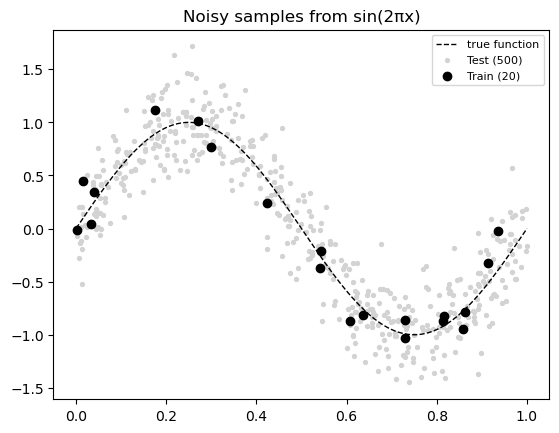

In [10]:
#### Make fake data ####

def true_f(x):
    """Data distribution: sin(2 * pi * x). Feel free to change it. """
    return np.sin(2 * np.pi * x)

def make_data(n, seed, noise=0.25):
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(0, 1, n))
    return x.reshape(-1, 1), true_f(x) + rng.normal(0, noise, n)

X_train, y_train = make_data(20,  seed=0)
X_test,  y_test  = make_data(500, seed=2)

#### Plot data distribution ####
X_grid = np.linspace(0, 1, 400).reshape(-1, 1)

plt.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=1, label="true function")
plt.scatter(X_test, y_test, s=8, c="lightgrey", label="Test (500)")
plt.scatter(X_train, y_train, c="k", zorder=3, label="Train (20)")
plt.legend(fontsize=8); plt.title("Noisy samples from sin(2πx)"); plt.show()

### High-degree polynomial model

Fit a degree-15 polynomial model with ordinary least squares to 20 points (training data). 

In [11]:
#### Helper ####

def poly_model(estimator, degree=15):
    return make_pipeline(PolynomialFeatures(degree, include_bias=False),
                         StandardScaler(), estimator)

def report(name, predict_grid, predict_test, coefs):
    mse = mean_squared_error(y_test, predict_test)
    print(f"{name:<26} test MSE {mse:11.4f} | max|beta| {np.abs(coefs).max():12.3g}")

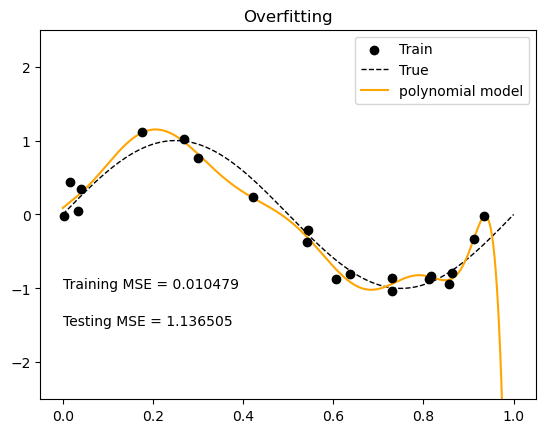

Beta: [ 1.67686315e+00 -7.52764324e+00  1.98406106e+02 -1.28745121e+03
  2.92419264e+03 -1.58653778e+03 -2.35904674e+03  9.73734975e+02
  2.73699884e+03  8.30077603e+02 -2.17439347e+03 -2.59901728e+03
  5.84471917e+02  3.69625407e+03 -1.93209774e+03]

OLS                        test MSE      1.1365 | max|beta|      3.7e+03


In [12]:
ols = poly_model(LinearRegression(), degree=15).fit(X_train, y_train)

plt.scatter(X_train, y_train, c="k", zorder=3, label="Train")
plt.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=1, label="True")
plt.plot(X_grid, ols.predict(X_grid), "orange", label="polynomial model")
plt.text(0, -1, f"Training MSE = {mean_squared_error(y_train, ols.predict(X_train)):.6f}")
plt.text(0, -1.5, f"Testing MSE = {mean_squared_error(y_test, ols.predict(X_test)):.6f}")
plt.ylim(-2.5, 2.5)
plt.legend()
plt.title("Overfitting")
plt.show()

print(f"Beta: {ols[-1].coef_}\n")
report("OLS", ols.predict(X_grid), ols.predict(X_test), ols[-1].coef_)

### Overfitting: High variance 

Refit the model on five different random training samples drawn from the same true function. Overfitting models highly depend on the training dataset. The scatter of the curves indicates the variance.

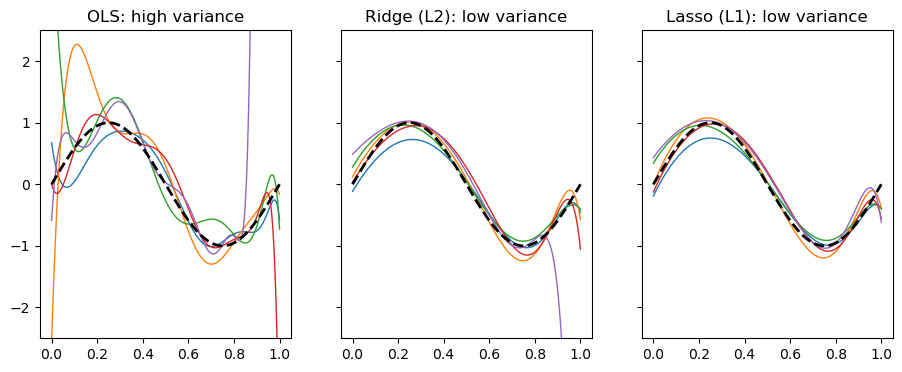

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
for ax, (title, esti) in zip(axes, [("OLS: high variance", LinearRegression()),
                                    ("Ridge (L2): low variance", Ridge(alpha=0.01)),   # alpha -> lambda (regularisation strength)
                                    ("Lasso (L1): low variance", Lasso(alpha=0.001))]):
    for seed in range(5):
        Xs, ys = make_data(20, seed=100 + seed)
        m = poly_model(esti).fit(Xs, ys)
        ax.plot(X_grid, m.predict(X_grid), lw=1)
    ax.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=2)
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(title)
plt.show()

### Ridge (L2)

$$L(\boldsymbol{\beta}) = \text{MSE}(\boldsymbol{\beta}) + \lambda \cdot \sum_j \boldsymbol{\beta}_j^2$$

In [scikit-learn: Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), $\lambda$ is called `alpha` argument. 

To choose an optimal alpha, one can use a built-in package [RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html)

Ridge alpha=0              test MSE      1.1365 | max|beta|      3.7e+03
Ridge alpha=1e-06          test MSE      0.3133 | max|beta|         38.3
Ridge alpha=0.001          test MSE      0.2186 | max|beta|         5.83
Ridge alpha=0.01           test MSE      0.1027 | max|beta|         3.55
Ridge alpha=0.1            test MSE      0.1273 | max|beta|         1.37
Ridge alpha=10             test MSE      0.2724 | max|beta|        0.181


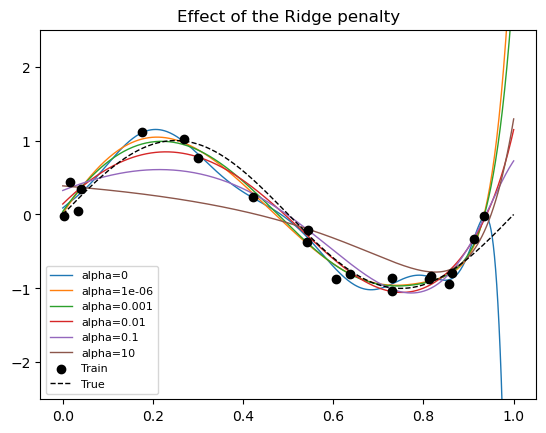

In [14]:
for a in [0.0, 1e-6, 1e-3, 1e-2, 1e-1, 10.0]:
    if a == 0:
        est = LinearRegression()
    else:
        est = Ridge(alpha=a)
    m = poly_model(est).fit(X_train, y_train)
    report(f"Ridge alpha={a:g}", m.predict(X_grid), m.predict(X_test), m[-1].coef_)
    plt.plot(X_grid, m.predict(X_grid), lw=1, label=f"alpha={a:g}")

plt.scatter(X_train, y_train, c="k", zorder=3, label="Train")
plt.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=1, label="True")
plt.ylim(-2.5, 2.5); plt.legend(fontsize=8); plt.title("Effect of the Ridge penalty"); plt.show()

### Lasso (L1) 

L1 penalises the absolute value of coefficients. The penalty is a constant, keep pushing the coefficients to zero. 

In [scikit-learn: Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html), the constant $\lambda$ is called `alpha` argument. 

To choose an optimal alpha, one can use a built-in package [LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html)

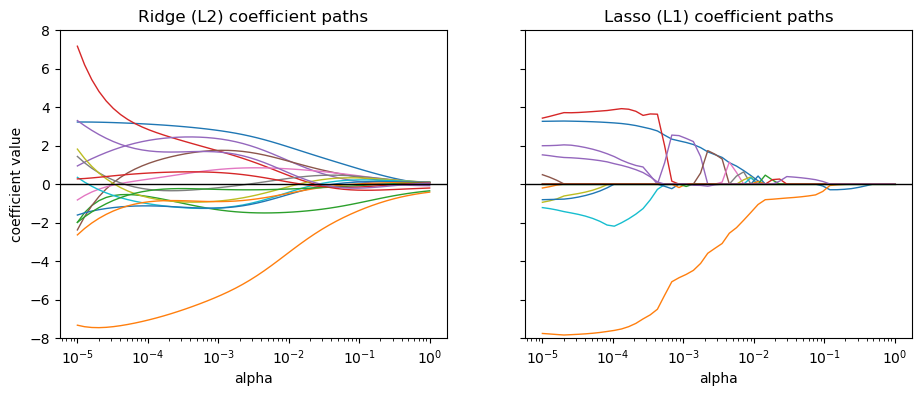

In [15]:
alphas_l = np.logspace(-5, 0, 50)
ridge_paths, lasso_paths = [], []
for a in alphas_l:
    ridge_paths.append(poly_model(Ridge(alpha=a)).fit(X_train, y_train)[-1].coef_)
    lasso_paths.append(poly_model(Lasso(alpha=a, max_iter=100000)).fit(X_train, y_train)[-1].coef_)
ridge_paths, lasso_paths = np.array(ridge_paths), np.array(lasso_paths)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, paths, name in zip(axes, [ridge_paths, lasso_paths], ["Ridge (L2)", "Lasso (L1)"]):
    ax.semilogx(alphas_l, paths, lw=1)
    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("alpha")
    ax.set_title(f"{name} coefficient paths")
axes[0].set_ylabel("coefficient value")
axes[0].set_ylim(-8, 8)
plt.show()

### Pick optimal alpha L2 and L1

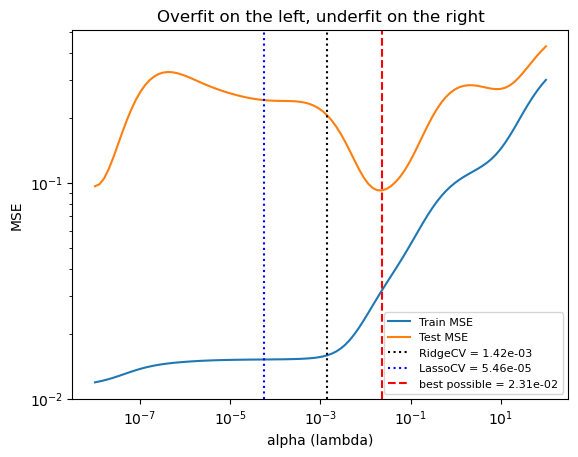

RidgeCV                    test MSE      0.2052 | max|beta|         5.58
LassoCV                    test MSE      0.1974 | max|beta|         7.74


In [16]:
#### Pick alpha ####

alphas = np.logspace(-8, 2, 100)
tr_curve, te_curve = [], []
for a in alphas:
    m = poly_model(Ridge(alpha=a)).fit(X_train, y_train)
    tr_curve.append(mean_squared_error(y_train, m.predict(X_train)))
    te_curve.append(mean_squared_error(y_test, m.predict(X_test)))

## Ridge L2
ridge_cv = poly_model(RidgeCV(alphas=alphas)).fit(X_train, y_train)
best_alpha_l2 = ridge_cv[-1].alpha_

## Lasso L1
lasso_cv = poly_model(LassoCV(alphas=alphas, cv=5, max_iter=100000)).fit(X_train, y_train)
best_alpha_l1 = lasso_cv[-1].alpha_

## Plot comparison
plt.loglog(alphas, tr_curve, label="Train MSE")
plt.loglog(alphas, te_curve, label="Test MSE")
plt.axvline(best_alpha_l2, color="k", ls=":", label=f"RidgeCV = {best_alpha_l2:.2e}")         # best alpha from RidgeCV based on very limited training data
plt.axvline(best_alpha_l1, color="b", ls=":", label=f"LassoCV = {best_alpha_l1:.2e}")         # best alpha from LassoCV based on very limited training data
plt.axvline(alphas[int(np.argmin(te_curve))], color="r", ls="--",
            label=f"best possible = {alphas[int(np.argmin(te_curve))]:.2e}")              # best possible alpha according to testing result
plt.xlabel("alpha (lambda)"); plt.ylabel("MSE"); plt.legend(fontsize=8)
plt.title("Overfit on the left, underfit on the right"); plt.show()

report("RidgeCV", ridge_cv.predict(X_grid), ridge_cv.predict(X_test), ridge_cv[-1].coef_)
report("LassoCV", lasso_cv.predict(X_grid), lasso_cv.predict(X_test), lasso_cv[-1].coef_)

### Data augmentation

This demonstration tries to fix the overfitting by increasing the number of data with copies. 

We simply add a small Gaussian noise on the existing training datasets.

training points: 20 -> 200
OLS (no augmentation)      test MSE      1.1365 | max|beta|      3.7e+03
OLS + augmentation         test MSE      0.0733 | max|beta|     1.52e+03


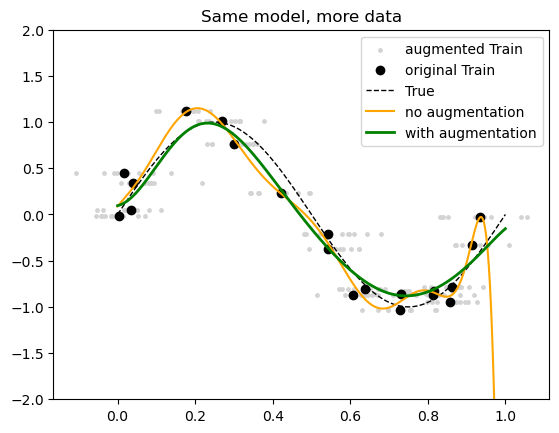

In [17]:
def augmentation(Xa, ya, n_copies=10, sigma=0.05, seed=None):
    rng = np.random.default_rng(seed)
    Xa_rep = np.repeat(Xa, n_copies, axis=0)
    ya_rep = np.repeat(ya, n_copies)
    return Xa_rep + rng.normal(0, sigma, Xa_rep.shape), ya_rep

X_a, y_a = augmentation(X_train, y_train)
print(f"training points: {len(y_train)} -> {len(y_a)}")

ols_aug = poly_model(LinearRegression()).fit(X_a, y_a)

report("OLS (no augmentation)", ols.predict(X_grid), ols.predict(X_test), ols[-1].coef_)
report("OLS + augmentation", ols_aug.predict(X_grid), ols_aug.predict(X_test), ols_aug[-1].coef_)

plt.scatter(X_a, y_a, s=6, c="lightgrey", label="augmented Train")
plt.scatter(X_train, y_train, c="k", label="original Train")
plt.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=1, label="True")
plt.plot(X_grid, ols.predict(X_grid), "orange", label="no augmentation")
plt.plot(X_grid, ols_aug.predict(X_grid), "g", lw=2, label="with augmentation")
plt.ylim(-2, 2)
plt.legend()
plt.title("Same model, more data")
plt.show()

### Comparison between remedies

In [18]:
rows = [
    ("OLS (baseline)", ols.predict(X_grid), ols.predict(X_test)),
    ("Ridge (CV alpha)",         ridge_cv.predict(X_grid), ridge_cv.predict(X_test)),
    ("Lasso (CV alpha)",         lasso_cv.predict(X_grid), lasso_cv.predict(X_test)),
    ("Data augmentation",        ols_aug.predict(X_grid), ols_aug.predict(X_test)),
]

print(f"{'method':<28}{'test MSE':>12}")
print("-" * 40)
for name, pg, pt in rows:
    mse = mean_squared_error(y_test, pt)
    print(f"{name:<28}{mse:12.4f}")
print(f"{'(true function)':<28}{0.0:12.4f}")


method                          test MSE
----------------------------------------
OLS (baseline)                    1.1365
Ridge (CV alpha)                  0.2052
Lasso (CV alpha)                  0.1974
Data augmentation                 0.0733
(true function)                   0.0000


# Session 3: Non-linear regressors

In the following exercises, we will try to use images' pixels as the input features to increase the dimension in feature space. Since we are not doing CNN, we will simply flatten the 2D images (with 3 bands) into one-dimensional array. 

In [47]:
#### Read data and construct initial datasets ####

image_dir = 'known_datasets_imgs/'
filenames = np.array([fn[:-4] for fn in os.listdir(image_dir) if fn.endswith('.jpg')])

newsize = 128   # Original image size (128, 128, 3) were probably too big and the overfitting problem would be too serious. 

#X = np.zeros((len(filenames), newsize, newsize, 3))              # Use this if you want to build CNN model
X = np.zeros((len(filenames), int(newsize * newsize * 3)))        # Use this for scikit-learn and NN models (keras)
Y = np.zeros((len(filenames)))

for ix, fn in enumerate(filenames):
    file_path = os.path.join(image_dir, fn + '.jpg')
    with Image.open(file_path) as img:
        img = img.convert('RGB').resize((newsize, newsize), Image.Resampling.LANCZOS) 
        ## Flatten to one-dimensional input ##
        X[ix] = np.array(img.resize((newsize, newsize))).flatten()
        ## For CNN input ## 
        #img = img.resize((newsize, newsize))
        #for ik in range(3):
        #    X[ix,:,:,ik] = np.array(img)[:,:,ik]
    Y[ix] = np.float64(fn[19:])

print(X.shape, Y.shape)

(2000, 768) (2000,)


In [48]:
#### Spilt training and testing data (80:20) ####

n_train = int(0.8 * len(filenames))
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1600, 768) (400, 768) (1600,) (400,)


### Recap using linear regression models

For comparison purpose, let's try linear regression models first.

In [ ]:
#### Type your code from here ####


## Tree-based regressor

Check the following websites and choose a tree-based algorithm for this task. If you have no preference, one can try the most basic one: `DecisionTreeRegressor`. 
- [sklearn.tree](https://scikit-learn.org/stable/api/sklearn.tree.html)
- [sklearn.ensemble](https://scikit-learn.org/stable/api/sklearn.ensemble.html)

In [ ]:
#### Type your code from here ####


## Neural Networks

An architecture template is provided based on the notebook of Wednesday's lecture. Check out the notebook from Wednesday's lecture to build your NN model for this task.

```python
def create_nn_model(input_shape=(128*128*3)):
    """
    Create a NN model for regression task.
    
    Args:
        input_shape: flatten images -> (height * width * channels)
    
    Returns:
        Compiled Keras model
    """
    model = models.Sequential([
        # Fully Connected Layers
        layers.Dense(32, activation='relu', name='dense1'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(16, activation='relu', name='dense2'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output Layer
        layers.Dense(1, activation='linear', name='output')
    ])

    return model
```

In [ ]:
#### Type your code from here ####


## Predict new datasets: images

The folder `new_datasets_imgs/` contains 5 galaxy images without stellar mass measurement. Build a non-linear regression model of your own choice, and record your answer for each galaxy on this [**Google Doc**](https://docs.google.com/document/d/1Wcu2wqmJlopgx4V42Fe1ZqupgcFVDA0xlR90FwoM_q4/edit?usp=sharing) (Session 3).

In [49]:
#### Read data ####

image_dir = 'new_datasets_imgs/'
filenames = np.array([fn[:-4] for fn in os.listdir(image_dir) if fn.endswith('.jpg')])

newsize = 16   # Original image size were probably too big and the overfitting problem would be too serious. 

#X = np.zeros((len(filenames), newsize, newsize, 3))              # Use this if you want to build CNN model
X = np.zeros((len(filenames), int(newsize * newsize * 3)))        # Use this for scikit-learn and NN models (keras)

for ix, fn in enumerate(filenames):
    file_path = os.path.join(image_dir, fn + '.jpg')
    with Image.open(file_path) as img:
        img = img.convert('RGB').resize((newsize, newsize), Image.Resampling.LANCZOS) 
        ## Flatten to one-dimensional input ##
        X[ix] = np.array(img.resize((newsize, newsize))).flatten()
        ## For CNN input ## 
        #img = img.resize((newsize, newsize))
        #for ik in range(3):
        #    X[ix,:,:,ik] = np.array(img)[:,:,ik]

print(X.shape)

(5, 768)


In [ ]:
#### Type your code from here ####
